## Tools in Langgraph

In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage , HumanMessage
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from langchain_core.tools import tool
import yfinance as yf
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

In [2]:
load_dotenv()

True

In [ ]:
model = ChatOpenAI(model = "gpt-5.4-mini-2026-03-17" , temperature = 0)
# model = ChatOpenAI(
#     model="openai/gpt-5.4-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
#     temperature=0,
# )

In [4]:
# Tools
search_tool = TavilySearch(max_results=3, topic="general")

@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation '{operation}'"}
        
        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {"error": str(e)}



@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA')
    using Yahoo Finance.
    """
    try:
        ticker = yf.Ticker(symbol)
        data = ticker.fast_info

        return {
            "symbol": symbol.upper(),
            "price": data.last_price,
            "currency": data.currency,
            "previous_close": data.previous_close,
            "day_high": data.day_high,
            "day_low": data.day_low,
        }
    except Exception as e:
        return {"error": str(e)}

In [5]:
tools = [search_tool, get_stock_price, calculator]
llm_with_tools = model.bind_tools(tools)

In [6]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [7]:
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

In [8]:
tool_node = ToolNode(tools)

In [9]:
## checkpointer
conn = sqlite3.connect(database="chatbot.db", check_same_thread=False)
checkpointer = SqliteSaver(conn=conn)

In [10]:
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat_node")

graph.add_conditional_edges("chat_node",tools_condition)

chatbot = graph.compile(checkpointer=checkpointer)

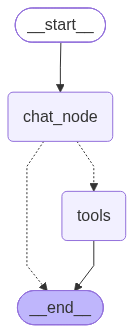

In [11]:
chatbot

In [12]:
config = {'configurable': {'thread_id': 'thread-5'}}

In [13]:
initial_state = {
    'messages': [HumanMessage(content='What are the latest developments in AI agents?')]
}

In [14]:
# Regular chat
response = chatbot.invoke(initial_state, config=config)
import pprint
pprint.pprint(response["messages"][-1].content)

('{"query": "latest developments in AI agents 2026 news recent breakthroughs '
 'agentic AI multi-agent frameworks autonomous agents", "follow_up_questions": '
 'null, "answer": null, "images": [], "results": [{"url": '
 '"https://aimultiple.com/agentic-ai-trends", "title": "10+ Agentic AI Trends '
 'and Examples for 2026 - AIMultiple", "content": "## Reference '
 'Links\\n\\n1.\\n\\nMonte Carlo Launches Observability Agents To Accelerate '
 'Data + AI Monitoring And Troubleshooting2.\\n\\nBuilding Fully Autonomous '
 'Data Analysis Pipelines with the PraisonAI Agent Framework: A Coding '
 'Implementation - MarkTechPost\\n\\nMarkTechPost AI Media Inc3.\\n\\nNVIDIA '
 'and GE HealthCare Collaborate to Advance the Development of Autonomous '
 'Diagnostic Imaging With Physical AI | NVIDIA Newsroom4.\\n\\nBusiness '
 'Pricing | OpenAI5.\\n\\nSurfelGAN: Synthesizing Realistic Sensor Data for '
 'Autonomous Driving\\n\\nWaymo6.\\n\\nAI agent vs human agent cost: A '
 'practical 2026 comparis

In [15]:
response

{'messages': [HumanMessage(content='What are the latest developments in AI agents?', additional_kwargs={}, response_metadata={}, id='f1a2a87b-4632-45ce-bb63-13dc1fe264b6'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 1359, 'total_tokens': 1419, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EE4mi5qTEsJX5cI5jQ705EUMKiZk0', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a012e9-90bb-7833-a3ce-98a30dc7b61f-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'latest developments in AI agents 2026 news recent breakthroughs agentic AI multi-agent frame

In [16]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is 2*3?")]}, config=config)
print(out["messages"][-1].content)

2 × 3 = 6


In [17]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is the stock price of apple")]},config=config)
print(out["messages"][-1].content)

{"symbol": "AAPL", "price": 305.5899963378906, "currency": "USD", "previous_close": 305.7705, "day_high": 307.6600036621094, "day_low": 302.9389953613281}


## structuring the response by looping the answer back to llm

In [18]:
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat_node")

graph.add_conditional_edges("chat_node",tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot2 = graph.compile(checkpointer=checkpointer)

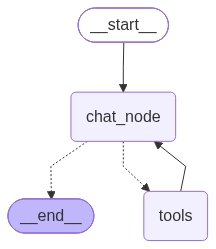

In [19]:
chatbot2


In [20]:
config = {'configurable': {'thread_id': 'thread-6'}}

In [21]:
# Chat requiring tool
out = chatbot2.invoke({"messages": [HumanMessage(content="What is 2*3?")]},config=config)
print(out["messages"][-1].content)

6


In [22]:
# Chat requiring tool
out = chatbot2.invoke({"messages": [HumanMessage(content="What is the stock price of apple")]},config=config)
print(out["messages"][-1].content)

Apple (AAPL) is trading at **$305.59 USD** right now.


In [23]:
# Chat requiring mutiple hops of tool call
out = chatbot2.invoke({"messages": [HumanMessage(content="First find out the stock price of Apple using get stock price tool then use the calculator tool to find out how much will it take to purchase 50 shares?")]},config=config)
print(out["messages"][-1].content)

Apple’s stock price is **$305.59 per share**.

For **50 shares**, it would cost **$15,279.50 USD** (before any fees or taxes).
